## MERFISH mouse liver: Notebook to determine ROIs for overlapping cells in 3d spot-based transcriptomics data

This notebook contains a prototype implementation of an ovrl.py analysis script for vizgen's MERFISH liver showcase data set. It runs tha basic ovrlpy analysis pipeline and stores the result;

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from matplotlib_scalebar.scalebar import ScaleBar

import ovrlpy

In [2]:
import pickle

with open("../merscope_liver.pickle", "rb") as file:
    liver = pickle.load(file)

coordinate_df = liver.transcripts.to_pandas()

In [3]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)

In [4]:
# crop out a central part of the tissue to create artificial overlaps:
xb_, _xb, yb_, _yb = 5000, 5800, 3000, 3800
xt_, _xt, yt_, _yt = 2200, 3000, 1800, 2600
fold_bottom_mask = coordinate_df.x.between(xb_, _xb) & coordinate_df.y.between(yb_, _yb)
fold_top_mask = coordinate_df.x.between(xt_, _xt) & coordinate_df.y.between(yt_, _yt)

fold_df_bottom = coordinate_df[fold_bottom_mask].copy()
fold_df_bottom["fold"] = "bottom"
fold_df_top = coordinate_df[fold_top_mask].copy()
fold_df_top["fold"] = "top"

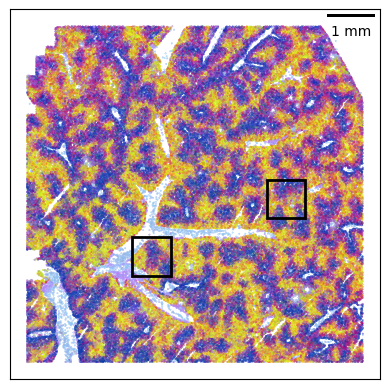

In [5]:
fig, ax = plt.subplots()
ax.scatter(
    x=liver.pseudocells.obsm["spatial"][:, 0],
    y=liver.pseudocells.obsm["spatial"][:, 1],
    c=liver.pseudocells.obsm["RGB"],
    s=0.1,
)

box_kwargs = dict(edgecolor="k", facecolor="none", lw=2)

ax.add_artist(plt.Rectangle((xb_, yb_), _xb - xb_, _yb - yb_, **box_kwargs))
ax.add_artist(plt.Rectangle((xt_, yt_), _xt - xt_, _yt - yt_, **box_kwargs))

ax.set_xticks([])
ax.set_yticks([])

ax.add_artist(ScaleBar(1, units="um", box_alpha=0))

_ = ax.set(aspect="equal")

In [6]:
fold_df_bottom.x -= xb_
fold_df_top.x -= xt_

fold_df_bottom.y -= yb_
fold_df_top.y -= yt_

fold_df_folded = fold_df_bottom.copy()
fold_df_folded.z -= fold_df_bottom.z.max() - fold_df_top.z.min()
fold_df_folded = pd.concat([fold_df_folded, fold_df_top])

In [7]:
liver.transcripts = pl.from_pandas(fold_df_bottom)
# brain.KDE_bandwidth = 2.5

liver.process_coordinates(shift=False)
liver.compute_VSI()

coherence_bottom = liver.integrity_map.copy()
signal_bottom = liver.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


In [8]:
liver.transcripts = pl.from_pandas(fold_df_top)
# brain.KDE_bandwidth = 1

liver.process_coordinates(shift=False)
liver.compute_VSI()

coherence_top = liver.integrity_map.copy()
signal_top = liver.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.32it/s]


In [9]:
liver.transcripts = pl.from_pandas(fold_df_folded)
# brain.KDE_bandwidth = 1

liver.process_coordinates(shift=False)
liver.compute_VSI()

coherence_folded = liver.integrity_map.copy()
signal_folded = liver.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.17it/s]


In [10]:
# ensure same size
shape = tuple(max(*x) for x in zip(signal_bottom.shape, signal_top.shape))


def ensure_shape(x, shape):
    y = np.zeros(shape, dtype=x.dtype)
    y[: x.shape[0], : x.shape[1]] = x
    return y


coherence_top = ensure_shape(coherence_top, shape)
signal_top = ensure_shape(signal_top, shape)
coherence_bottom = ensure_shape(coherence_bottom, shape)
signal_bottom = ensure_shape(signal_bottom, shape)

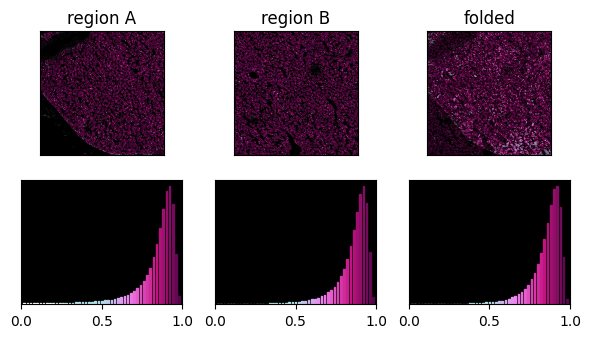

In [19]:
from ovrlpy._plotting import BIH_CMAP as cmap

centimeter = 1 / 2.54


def plot_purity_distribution(ax, coherence, density=None):
    vals, bins = np.histogram(coherence, bins=50, range=(0, 1), density=density)
    colors = cmap(bins[1:-1])
    bars = ax.bar(bins[1:-1], vals[1:], width=0.01)
    for i, bar in enumerate(bars):
        bar.set_color(colors[i])
    ax.set(xlim=(0, 1))


def plot_image(ax, coherence, signal, title=None):
    ax.imshow(
        coherence,
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        alpha=signal / signal.max(),
        interpolation="nearest",
    )
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title)


fig, axs = plt.subplots(2, 3, figsize=(18 * centimeter, 9 * centimeter))

plot_image(axs[0, 0], coherence_top, signal_top, "region A")
plot_purity_distribution(axs[1, 0], coherence_top[signal_bottom > 1.5])

plot_image(axs[0, 1], coherence_bottom, signal_bottom, "region B")
plot_purity_distribution(axs[1, 1], coherence_bottom[signal_top > 1.5])

plot_image(axs[0, 2], coherence_folded, signal_folded, "folded")
plot_purity_distribution(axs[1, 2], coherence_folded[signal_folded > 1.5])

for ax in axs.ravel():
    ax.set(facecolor="k")
    ax.set_yticks([])

plt.savefig(out_dir / "purity_summary.svg", dpi=600)

/tmp/ipykernel_3852736/3596782411.py:10: RuntimeWarning: divide by zero encountered in divide
  hist_quotient = hist_folded / ((hist_top + hist_bot) / 2)


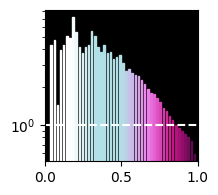

In [16]:
hist_top, _ = np.histogram(
    coherence_top[signal_top > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_bot, _ = np.histogram(
    coherence_bottom[signal_bottom > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_folded, bins = np.histogram(
    coherence_folded[signal_folded > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_quotient = hist_folded / ((hist_top + hist_bot) / 2)

fig, ax = plt.subplots(figsize=(5 * centimeter, 5 * centimeter))

ax.set(facecolor="k", xlim=(0, 1))
colors = cmap(bins[1:-1])
bars = ax.bar(bins[1:-1], hist_quotient[1:], width=0.01)
for i, bar in enumerate(bars):
    bar.set_color(colors[i])

ax.set_yscale("log")
plt.hlines(1, 0, 1, linestyles="dashed", color="w")

fig.savefig(out_dir / "purity_quotient.svg", dpi=300)